# Robomimic Dataset Exploration

Spec Sheet Step 2: explore the raw HDF5 **before** writing conversion code.
Findings here feed directly into `conversion/convert_robomimic.py` and `EXPLORATION_NOTES.md`.

In [10]:
import h5py
import numpy as np

HDF5_PATH = r"C:\Users\naqee\OneDrive\Desktop\CSC415 Project\data\raw\robomimic\lift\ph\image.hdf5"

f = h5py.File(HDF5_PATH, 'r')

## 1. Top-level structure

In [11]:
print("Top-level keys:   ", list(f.keys()))
print("Number of demos:  ", len(f['data'].keys()))
print("First 5 demo keys:", list(f['data'].keys())[:5])
print("Mask keys:        ", list(f['mask'].keys()) if 'mask' in f else "no mask group")
print()
# Check dataset-level attributes
print("File attrs:", dict(f.attrs))
if 'data' in f:
    print("data attrs:", dict(f['data'].attrs))

Top-level keys:    ['data', 'mask']
Number of demos:   200
First 5 demo keys: ['demo_0', 'demo_1', 'demo_10', 'demo_100', 'demo_101']
Mask keys:         ['20_percent', '20_percent_train', '20_percent_valid', '50_percent', '50_percent_train', '50_percent_valid', 'train', 'valid']

File attrs: {}
data attrs: {'env_args': '{\n    "env_name": "Lift",\n    "env_version": "1.5.2",\n    "type": 1,\n    "env_kwargs": {\n        "has_renderer": false,\n        "has_offscreen_renderer": true,\n        "ignore_done": true,\n        "use_object_obs": true,\n        "use_camera_obs": true,\n        "control_freq": 20,\n        "controller_configs": {\n            "type": "BASIC",\n            "body_parts": {\n                "right": {\n                    "type": "OSC_POSE",\n                    "input_max": 1,\n                    "input_min": -1,\n                    "output_max": [\n                        0.05,\n                        0.05,\n                        0.05,\n                    

## 2. Demo structure: actions

In [12]:
demo = f['data/demo_0']
print("Demo keys:", list(demo.keys()))
print("Demo attrs:", dict(demo.attrs))
print()

a = demo['actions'][:]
print(f"Actions shape:        {a.shape}")
print(f"Actions dtype:        {a.dtype}")
print(f"Actions min per dim:  {a.min(0).round(5)}")
print(f"Actions max per dim:  {a.max(0).round(5)}")
print(f"Actions mean per dim: {a.mean(0).round(5)}")
print()
# Check a few demo lengths to see if they vary
lengths = [f[f'data/{k}']['actions'].shape[0] for k in list(f['data'].keys())[:10]]
print(f"First 10 demo lengths: {lengths}")

Demo keys: ['actions', 'dones', 'next_obs', 'obs', 'rewards', 'states']
Demo attrs: {'camera_info': '{\n    "agentview": {\n        "intrinsics": [\n            [\n                101.39696961966999,\n                0.0,\n                42.0\n            ],\n            [\n                0.0,\n                101.39696961966999,\n                42.0\n            ],\n            [\n                0.0,\n                0.0,\n                1.0\n            ]\n        ],\n        "extrinsics": [\n            [\n                0.0,\n                0.706147235326418,\n                -0.7080650267036611,\n                0.5\n            ],\n            [\n                1.0,\n                0.0,\n                0.0,\n                0.0\n            ],\n            [\n                0.0,\n                -0.7080650267036611,\n                -0.706147235326418,\n                1.35\n            ],\n            [\n                0.0,\n                0.0,\n                0.0,

## 3. Observation keys, shapes, dtypes

In [13]:
print("Obs keys:")
for k in demo['obs'].keys():
    d = demo[f'obs/{k}']
    line = f"  {k}: shape={d.shape} dtype={d.dtype}"
    if 'image' in k:
        arr = d[0]
        line += f"  | pixel range=[{arr.min()}, {arr.max()}]"
    print(line)

Obs keys:
  agentview_image: shape=(59, 84, 84, 3) dtype=uint8  | pixel range=[10, 255]
  object: shape=(59, 10) dtype=float64
  robot0_eef_pos: shape=(59, 3) dtype=float64
  robot0_eef_quat: shape=(59, 4) dtype=float64
  robot0_eef_quat_site: shape=(59, 4) dtype=float32
  robot0_eye_in_hand_image: shape=(59, 84, 84, 3) dtype=uint8  | pixel range=[7, 254]
  robot0_gripper_qpos: shape=(59, 2) dtype=float64
  robot0_gripper_qvel: shape=(59, 2) dtype=float64
  robot0_joint_acc: shape=(59, 7) dtype=float64
  robot0_joint_pos: shape=(59, 7) dtype=float64
  robot0_joint_pos_cos: shape=(59, 7) dtype=float64
  robot0_joint_pos_sin: shape=(59, 7) dtype=float64
  robot0_joint_vel: shape=(59, 7) dtype=float64


## 4. Visual check: first frame from each camera

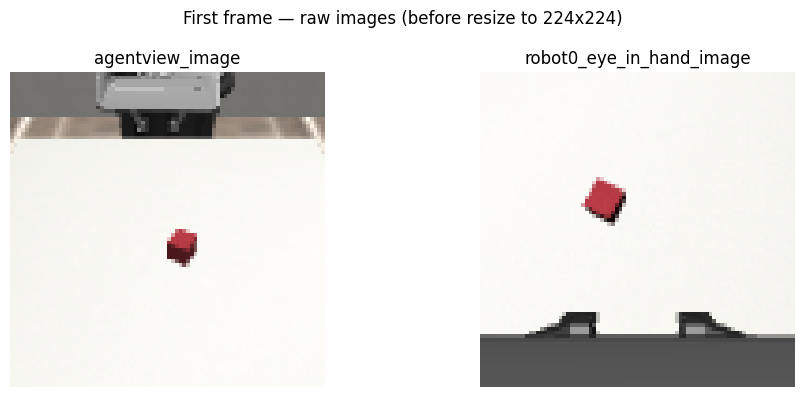

Camera keys found: ['agentview_image', 'robot0_eye_in_hand_image']


In [14]:
import matplotlib.pyplot as plt

image_keys = [k for k in demo['obs'].keys() if 'image' in k]
fig, axes = plt.subplots(1, len(image_keys), figsize=(5 * len(image_keys), 4))
if len(image_keys) == 1:
    axes = [axes]

for ax, k in zip(axes, image_keys):
    ax.imshow(demo[f'obs/{k}'][0])
    ax.set_title(k)
    ax.axis('off')

plt.suptitle("First frame — raw images (before resize to 224x224)")
plt.tight_layout()
plt.savefig("camera_frames.png", dpi=100)
plt.show()
print(f"Camera keys found: {image_keys}")

## 5. Action trajectory for demo_0

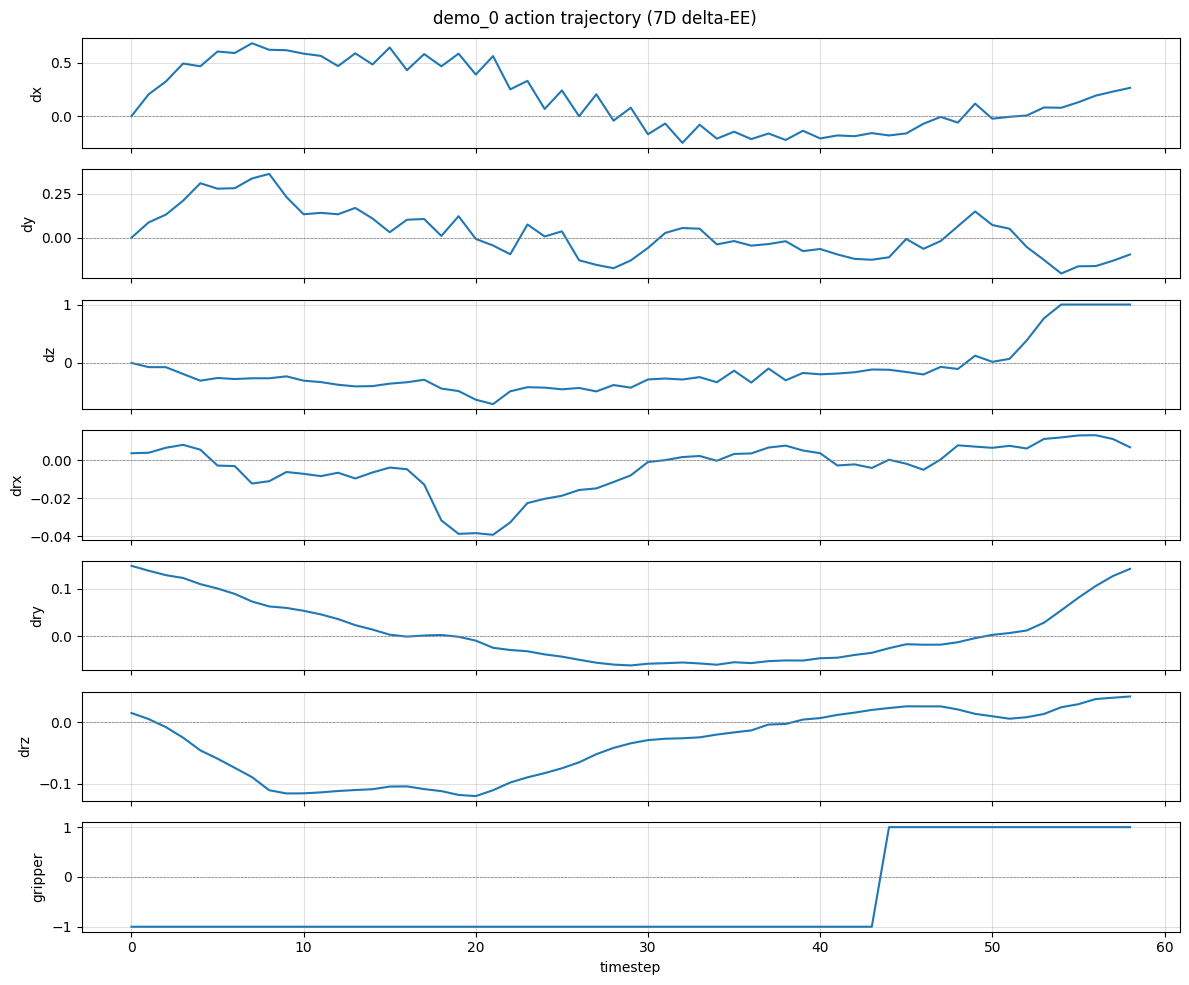

In [15]:
labels = ['dx', 'dy', 'dz', 'drx', 'dry', 'drz', 'gripper']
fig, axes = plt.subplots(7, 1, figsize=(12, 10), sharex=True)
for i, (ax, label) in enumerate(zip(axes, labels)):
    ax.plot(a[:, i])
    ax.set_ylabel(label)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.grid(True, alpha=0.4)
axes[-1].set_xlabel('timestep')
plt.suptitle('demo_0 action trajectory (7D delta-EE)')
plt.tight_layout()
plt.savefig("action_trajectory.png", dpi=100)
plt.show()

## 6. Normalization stats across ALL training demos

In [16]:
# Use 'train' mask if available, else all demos
if 'mask' in f and 'train' in f['mask']:
    train_keys = [k.decode() if isinstance(k, bytes) else k for k in f['mask']['train'][:]]
    print(f"Using mask/train: {len(train_keys)} demos")
else:
    train_keys = list(f['data'].keys())
    print(f"No mask found, using all {len(train_keys)} demos")

all_actions = np.concatenate([f[f'data/{k}/actions'][:] for k in train_keys], axis=0)
print(f"\nTotal timesteps: {all_actions.shape[0]}")
print(f"\nPer-dim mean: {all_actions.mean(0).round(5)}")
print(f"Per-dim std:  {all_actions.std(0).round(5)}")
print(f"Per-dim min:  {all_actions.min(0).round(5)}")
print(f"Per-dim max:  {all_actions.max(0).round(5)}")

Using mask/train: 180 demos

Total timesteps: 8640

Per-dim mean: [ 0.1735   0.00637 -0.16992  0.00329  0.00544  0.01353 -0.40556]
Per-dim std:  [0.2603  0.13074 0.49634 0.0224  0.06312 0.08538 0.91407]
Per-dim min:  [-1.      -0.56    -1.      -0.15066 -0.1404  -0.51798 -1.     ]
Per-dim max:  [1.      0.652   1.      0.11864 0.30509 0.46516 1.     ]


## 7. Cleanup

In [17]:
f.close()
print("Done. Paste the output of cells 1-6 into the chat.")

Done. Paste the output of cells 1-6 into the chat.
